In [1]:
%pip install -q python-terrier matplotlib nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports + init PyTerrier

In [2]:
import json
import re
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt

import nltk
for pkg in ["punkt", "punkt_tab", "wordnet", "omw-1.4", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

if not pt.started():
    pt.init()

C:\Users\User\AppData\Local\Temp\ipykernel_20700\2351888330.py:23: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
C:\Users\User\AppData\Local\Temp\ipykernel_20700\2351888330.py:24: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


 Charger la collection tweets

In [3]:
tweets_path = Path("tweets.jsonl")

docs = []
with tweets_path.open("r", encoding="utf-8") as f:
    for line in f:
        x = json.loads(line)
        docs.append({
            "docno": str(x["docno"]),
            "text": x.get("text", "") or "",
            "url": x.get("url", "") or "",
            "source": x.get("source", "") or "",
        })

docs_df = pd.DataFrame(docs)
print("Nb docs:", len(docs_df))
docs_df.head(3)

Nb docs: 500


,docno,text,url,source
0,3fcdb9735ec81d75,Iran has escaped collapse and regime change. U...,https://x.com/AkdKli/status/2045167048649507046,x.com
1,f5db3a28381e9607,This is a surgical dismantling of of a murder...,https://x.com/neurowaxx/status/204516367424383...,x.com
2,a5d3b15df7b31ca7,Netanyahu’s gambling that the Iran regime will...,https://x.com/Livelongandpr18/status/204516344...,x.com


Charger les requêtes depuis topics.xml

In [4]:
topics_path = Path("topics.xml")
root = ET.parse(topics_path).getroot()

topics = []
for topic in root.findall("topic"):
    qid = topic.attrib["number"].strip()
    query = topic.find("query").text.strip()
    topics.append({"qid": qid, "query": query})

topics_df = pd.DataFrame(topics)
print("Nb requêtes:", len(topics_df))
topics_df

Nb requêtes: 5


,qid,query
0,Q1,Iran regime collapse
1,Q2,Hormuz strait closure
2,Q3,Revolutionary Guard attack
3,Q4,Iran supreme leader speech
4,Q5,US bases Iran missiles


 Charger qrels.txt (format TREC)

In [5]:
qrels_path = Path("qrels.txt")

qrels_df = pd.read_csv(
    qrels_path,
    sep=r"\s+",
    header=None,
    names=["qid", "Q0", "docno", "label"],
    dtype={"qid": str, "Q0": str, "docno": str, "label": int},
)[["qid", "docno", "label"]]

print("Nb qrels:", len(qrels_df))
qrels_df.head(5)

Nb qrels: 500


,qid,docno,label
0,Q1,3fcdb9735ec81d75,1
1,Q1,f5db3a28381e9607,1
2,Q1,a5d3b15df7b31ca7,1
3,Q1,fbfdd0aee2d88a35,1
4,Q1,5be6f42915ac8782,1


## Indexation – 3 configurations

On compare trois représentations des termes :
- **Lexèmes** : tokens bruts (juste minusculisation), pas de stemming, pas de lemmatisation
- **Stems** : racines via le stemmer Porter (Terrier)
- **Lemmes** : lemmatisation via NLTK `WordNetLemmatizer` (avec POS tagging)

In [6]:
# ---- Préparation des textes pour chaque configuration ----

_token_re = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ]+")

def tokenize(text: str):
    return _token_re.findall((text or "").lower())

# Lexèmes : tokens bruts
def text_lexemes(text: str) -> str:
    return " ".join(tokenize(text))

# Stems : on laisse Terrier appliquer le stemmer Porter (texte = lexèmes)
text_stems = text_lexemes

# Lemmes : lemmatisation WordNet avec POS
_lemmatizer = WordNetLemmatizer()

def _wn_pos(tag: str):
    if tag.startswith("J"): return wordnet.ADJ
    if tag.startswith("V"): return wordnet.VERB
    if tag.startswith("N"): return wordnet.NOUN
    if tag.startswith("R"): return wordnet.ADV
    return wordnet.NOUN

def text_lemmas(text: str) -> str:
    toks = tokenize(text)
    if not toks:
        return ""
    try:
        tagged = nltk.pos_tag(toks)
    except Exception:
        tagged = [(t, "NN") for t in toks]
    return " ".join(_lemmatizer.lemmatize(t, _wn_pos(p)) for t, p in tagged)

def build_docs(transform_fn):
    out = []
    for r in docs_df.itertuples(index=False):
        out.append({
            "docno": str(r.docno),
            "text": transform_fn(r.text),
            "url": r.url,
            "source": r.source,
        })
    return out

# ---- 3 indexes ----
configs = {
    "lexemes":  {"transform": text_lexemes, "stemmer": "none",   "stopwords": None},
    "stems":    {"transform": text_stems,   "stemmer": "porter", "stopwords": "terrier"},
    "lemmes":   {"transform": text_lemmas,  "stemmer": "none",   "stopwords": "terrier"},
}

base_index_dir = (Path.cwd() / "index").resolve()
indexrefs = {}

for name, cfg in configs.items():
    idx_path = base_index_dir / f"pyterrier_{name}"
    if idx_path.exists():
        shutil.rmtree(idx_path)
    idx_path.mkdir(parents=True, exist_ok=True)

    indexer = pt.IterDictIndexer(
        str(idx_path),
        overwrite=True,
        meta={"docno": 32, "url": 256, "source": 64},
        stemmer=cfg["stemmer"],
        stopwords=cfg["stopwords"],
    )
    indexrefs[name] = indexer.index(build_docs(cfg["transform"]))
    stats = pt.IndexFactory.of(indexrefs[name]).getCollectionStatistics()
    print(f"[{name}] docs={stats.getNumberOfDocuments()} | uniq_terms={stats.getNumberOfUniqueTerms()} | tokens={stats.getNumberOfTokens()}")

[lexemes] docs=500 | uniq_terms=3500 | tokens=20116
[stems] docs=500 | uniq_terms=2495 | tokens=11454
[lemmes] docs=500 | uniq_terms=2680 | tokens=11411


### Aperçu des termes pour chaque index

In [7]:
def top_terms(indexref, n=15):
    idx = pt.IndexFactory.of(indexref)
    rows = []
    it = idx.getLexicon().iterator()
    while it.hasNext():
        kv = it.next()
        e = kv.getValue()
        rows.append({"term": kv.getKey(), "df": int(e.getDocumentFrequency()), "cf": int(e.getFrequency())})
    return pd.DataFrame(rows).sort_values("cf", ascending=False).head(n).reset_index(drop=True)

previews = {name: top_terms(ref, 15) for name, ref in indexrefs.items()}
for name, df in previews.items():
    print(f"\n=== {name} (top 15 par fréquence) ===")
    print(df.to_string(index=False))


=== lexemes (top 15 par fréquence) ===
  term  df   cf
   the 423 1155
    of 315  629
  iran 395  533
   and 287  437
    to 250  383
    in 247  343
     a 255  335
     s 203  298
    is 182  260
    us 176  258
  that 159  203
    on 157  194
hormuz 140  159
regime 120  156
strait 137  156

=== stems (top 15 par fréquence) ===
         term  df  cf
         iran 395 535
       attack 136 161
       hormuz 140 159
        regim 120 158
       strait 137 156
       missil 120 135
      iranian 113 124
         base 106 122
         will  88 116
      collaps 103 110
        guard 100 109
       closur 101 107
       israel  86 107
revolutionari 100 105
          war  77  94

=== lemmes (top 15 par fréquence) ===
         term  df  cf
         iran 395 534
       hormuz 140 159
       attack 134 159
       regime 120 158
       strait 137 156
      missile 119 132
      iranian 112 123
         base 106 122
         will  88 116
     collapse 103 110
        guard 100 109
       isra

In [8]:
# Comparaison globale de la taille de vocabulaire entre configurations
vocab_stats = []
for name, ref in indexrefs.items():
    s = pt.IndexFactory.of(ref).getCollectionStatistics()
    vocab_stats.append({
        "config": name,
        "nb_docs": s.getNumberOfDocuments(),
        "nb_termes_uniques": s.getNumberOfUniqueTerms(),
        "nb_tokens": s.getNumberOfTokens(),
    })
pd.DataFrame(vocab_stats)

,config,nb_docs,nb_termes_uniques,nb_tokens
0,lexemes,500,3500,20116
1,stems,500,2495,11454
2,lemmes,500,2680,11411


## Recherche – TF-IDF & BM25 sur les 3 configurations

On exécute deux modèles classiques fournis par PyTerrier :
- **TF-IDF** : modèle vectoriel simple
- **BM25** : modèle probabiliste

…appliqués à chacun des 3 index (lexèmes / stems / lemmes), soit 6 systèmes au total. Top 30 documents par requête.

In [9]:
MODELS = ["TF_IDF", "BM25"]

# Pour chaque config, on prépare les topics (les requêtes doivent suivre le même prétraitement)
topics_per_config = {
    "lexemes": topics_df.assign(query=topics_df["query"].map(text_lexemes)),
    "stems":   topics_df.assign(query=topics_df["query"].map(text_stems)),
    "lemmes":  topics_df.assign(query=topics_df["query"].map(text_lemmas)),
}

retrievers = {}   # nom -> BatchRetrieve
runs = {}         # nom -> dataframe résultats

for cfg_name, ref in indexrefs.items():
    for m in MODELS:
        name = f"{m}_{cfg_name}"
        retrievers[name] = pt.BatchRetrieve(ref, wmodel=m, num_results=30)
        runs[name] = retrievers[name].transform(topics_per_config[cfg_name])
        print(f"{name}: {len(runs[name])} lignes, {runs[name]['qid'].nunique()} requêtes")

# Aperçu : top 30 BM25/stems pour Q1
sample_name = "BM25_stems"
runs[sample_name].query("qid == 'Q1'")[['qid', 'docno', 'score', 'rank']].head(30)

C:\Users\User\AppData\Local\Temp\ipykernel_20700\2357686593.py:16: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  retrievers[name] = pt.BatchRetrieve(ref, wmodel=m, num_results=30)
C:\Users\User\AppData\Local\Temp\ipykernel_20700\2357686593.py:16: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  retrievers[name] = pt.BatchRetrieve(ref, wmodel=m, num_results=30)


TF_IDF_lexemes: 150 lignes, 5 requêtes
BM25_lexemes: 150 lignes, 5 requêtes
TF_IDF_stems: 150 lignes, 5 requêtes
BM25_stems: 150 lignes, 5 requêtes
TF_IDF_lemmes: 150 lignes, 5 requêtes
BM25_lemmes: 150 lignes, 5 requêtes


C:\Users\User\AppData\Local\Temp\ipykernel_20700\2357686593.py:16: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  retrievers[name] = pt.BatchRetrieve(ref, wmodel=m, num_results=30)
C:\Users\User\AppData\Local\Temp\ipykernel_20700\2357686593.py:16: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  retrievers[name] = pt.BatchRetrieve(ref, wmodel=m, num_results=30)
C:\Users\User\AppData\Local\Temp\ipykernel_20700\2357686593.py:16: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  retrievers[name] = pt.BatchRetrieve(ref, wmodel=m, num_results=30)
C:\Users\User\AppData\Local\Temp\ipykernel_20700\2357686593.py:16: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0

,qid,docno,score,rank
0,Q1,a2193c4052838008,2.975705,0
1,Q1,f5db3a28381e9607,2.677630,1
2,Q1,1c0bb2b2fa2121b8,2.677630,2
3,Q1,782eb9fe28396faa,2.566572,3
4,Q1,bd51c866aaded72d,2.498328,4
5,Q1,31efc8ca23f3043d,2.465434,5
6,Q1,e0a358186114dbb1,2.465434,6
7,Q1,a77df25dafc79883,2.465434,7
8,Q1,501b8de595d9b635,2.465434,8
9,Q1,477f38ee2199b109,2.465434,9


## Évaluation
Métriques calculées : **MAP**, **P@3**, **P@5**, **Précision** (P@30), **Rappel** (recall@30).

In [10]:
metrics = ["map", "P_3", "P_5", "P_30", "recall_30"]

# pyterrier exige un seul jeu de topics. On évalue donc chaque (modèle, config) séparément
# puis on agrège les résultats dans un seul tableau.
rows = []
for cfg_name in indexrefs.keys():
    sys_names = [f"{m}_{cfg_name}" for m in MODELS]
    sys_obj   = [retrievers[n] for n in sys_names]
    res = pt.Experiment(
        sys_obj,
        topics_per_config[cfg_name],
        qrels_df,
        eval_metrics=metrics,
        names=sys_names,
        round=4,
        filter_by_qrels=False,
    )
    rows.append(res)

exp = pd.concat(rows, ignore_index=True)
exp = exp.rename(columns={"P_3": "P@3", "P_5": "P@5", "P_30": "Précision (P@30)", "recall_30": "Rappel (R@30)", "map": "MAP"})
exp = exp.sort_values("MAP", ascending=False).reset_index(drop=True)
exp

,name,MAP,P@3,P@5,Précision (P@30),Rappel (R@30)
0,BM25_lexemes,0.1709,0.3333,0.40,0.3800,0.3800
1,TF_IDF_stems,0.1665,0.2000,0.28,0.3867,0.3867
2,TF_IDF_lemmes,0.1620,0.2000,0.28,0.3800,0.3800
3,TF_IDF_lexemes,0.1525,0.1333,0.28,0.3800,0.3800
4,BM25_stems,0.1479,0.2667,0.28,0.3467,0.3467
5,BM25_lemmes,0.1442,0.3333,0.28,0.3400,0.3400


### Détail par requête

In [11]:
pq_rows = []
for cfg_name in indexrefs.keys():
    sys_names = [f"{m}_{cfg_name}" for m in MODELS]
    sys_obj   = [retrievers[n] for n in sys_names]
    res = pt.Experiment(
        sys_obj,
        topics_per_config[cfg_name],
        qrels_df,
        eval_metrics=metrics,
        names=sys_names,
        perquery=True,
        round=4,
        filter_by_qrels=False,
    )
    pq_rows.append(res)

per_query = pd.concat(pq_rows, ignore_index=True)
per_query.head(20)

,name,qid,measure,value
0,BM25_lexemes,Q1,map,0.2044
1,BM25_lexemes,Q1,P_3,0.3333
2,BM25_lexemes,Q1,P_5,0.2000
3,BM25_lexemes,Q1,P_30,0.4667
4,BM25_lexemes,Q1,recall_30,0.4667
5,BM25_lexemes,Q2,map,0.1519
6,BM25_lexemes,Q2,P_3,0.6667
7,BM25_lexemes,Q2,P_5,0.6000
8,BM25_lexemes,Q2,P_30,0.3333
9,BM25_lexemes,Q2,recall_30,0.3333


## Courbe rappel / précision (interpolée à 11 points)

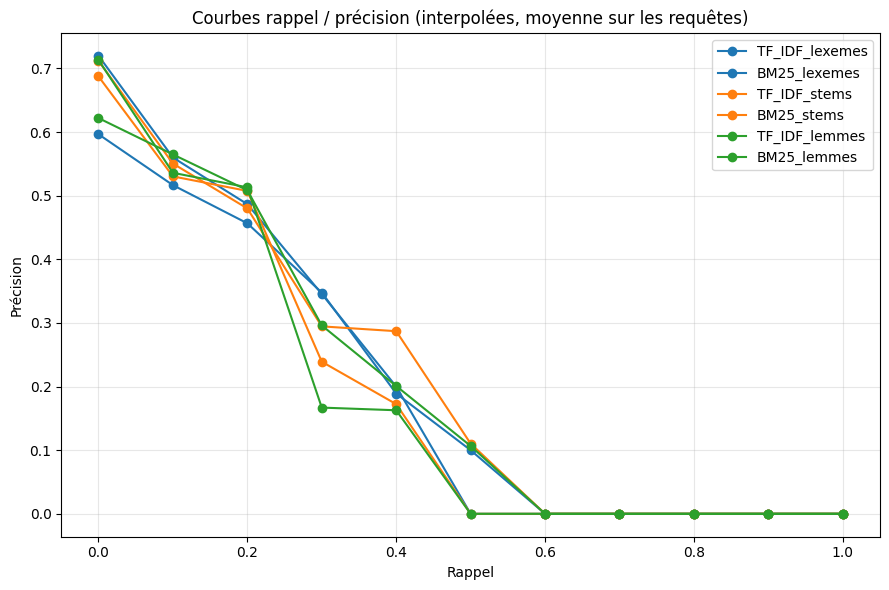

In [12]:
def interpolated_precision_recall(run_df, qrels_df, recall_levels=None):
    if recall_levels is None:
        recall_levels = np.linspace(0, 1, 11)

    qrels_lookup = {
        qid: set(group.loc[group["label"] > 0, "docno"].astype(str))
        for qid, group in qrels_df.groupby("qid")
    }

    curves = []
    for qid, group in run_df.groupby("qid"):
        relevant = qrels_lookup.get(qid, set())
        if not relevant:
            continue

        retrieved = group.sort_values("rank")["docno"].astype(str).tolist()
        hits = 0
        precisions, recalls = [], []
        for rank, docno in enumerate(retrieved, start=1):
            if docno in relevant:
                hits += 1
            precisions.append(hits / rank)
            recalls.append(hits / len(relevant))

        interp = []
        for level in recall_levels:
            cands = [p for p, r in zip(precisions, recalls) if r >= level]
            interp.append(max(cands) if cands else 0.0)
        curves.append(interp)

    if not curves:
        return pd.DataFrame({"recall": recall_levels, "precision": np.zeros(len(recall_levels))})
    mean_curve = np.mean(np.array(curves), axis=0)
    return pd.DataFrame({"recall": recall_levels, "precision": mean_curve})

# Une courbe par (modèle, configuration)
plt.figure(figsize=(9, 6))
styles = {"TF_IDF": "--", "BM25": "-"}
colors = {"lexemes": "tab:blue", "stems": "tab:orange", "lemmes": "tab:green"}

for name, run in runs.items():
    model, cfg = name.split("_", 1)
    curve = interpolated_precision_recall(run, qrels_df)
    plt.plot(curve["recall"], curve["precision"],
             marker="o", linestyle=styles.get(model, "-"),
             color=colors.get(cfg, None), label=name)

plt.title("Courbes rappel / précision (interpolées, moyenne sur les requêtes)")
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Export des résultats

In [13]:
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

exp.to_csv(results_dir / "pyterrier_model_comparison.csv", index=False)
per_query.to_csv(results_dir / "pyterrier_per_query.csv", index=False)

for name, run in runs.items():
    run.to_csv(results_dir / f"run_{name.lower()}_top30.csv", index=False)

print("Exports créés dans le dossier results/")

Exports créés dans le dossier results/
